# Urban Feature Extraction from CARTOSAT PAN Imagery
Pipeline:
1. Load Satellite Image
2. Normalize Image
3. Patch Extraction
4. Patch Filtering
5. Feature Extraction
6. Unsupervised Clustering
7. Pseudo Mask Generation
8. Dataset Preparation
9. U-Net Training
10. Evaluation Metrics

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

## 1. Load CARTOSAT Image

Image shape: (9985, 11269)


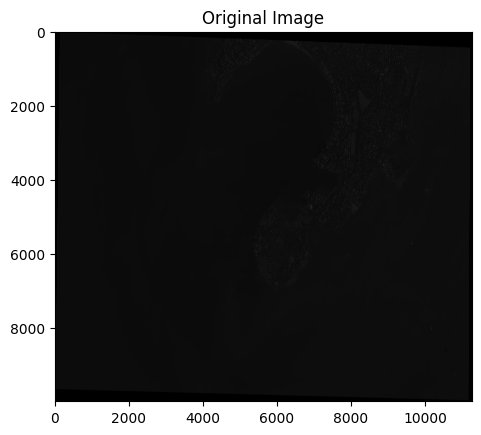

In [2]:
image_path = 'Monocromatic/CARTOSAT_1M_PAN.tif'

with rasterio.open(image_path) as src:
    image = src.read(1)
    meta = src.meta

print('Image shape:', image.shape)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.show()

## 2. Normalize Image

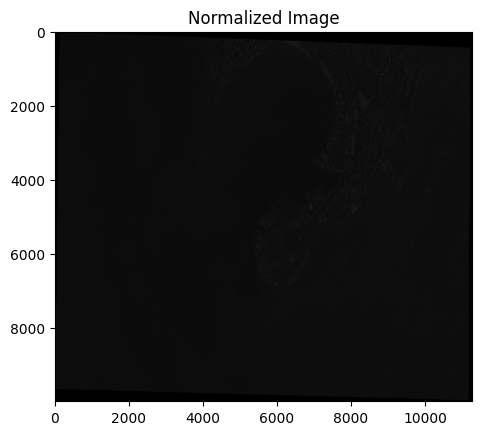

In [3]:
image = image.astype(np.float32)
image = (image - image.min()) / (image.max() - image.min())

plt.imshow(image, cmap='gray')
plt.title('Normalized Image')
plt.show()

## 3. Patch Extraction

In [4]:
def create_patches(image, patch_size=256):
    patches = []
    h, w = image.shape

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            if patch.shape == (patch_size, patch_size):
                patches.append(patch)
    return np.array(patches)

patches = create_patches(image)
print('Total patches:', patches.shape)

Total patches: (1716, 256, 256)


## 4. Patch Filtering (Threshold = 0.055)

In [5]:
def useful_patch(patch, threshold=0.055):
    return patch.mean() > threshold

filtered_patches = [p for p in patches if useful_patch(p)]
filtered_patches = np.array(filtered_patches)

print('Filtered patches:', filtered_patches.shape)

Filtered patches: (279, 256, 256)


## 5. Feature Extraction

In [6]:
features = []

for patch in filtered_patches:
    patch_uint8 = (patch * 255).astype('uint8')

    mean = patch.mean()
    std = patch.std()

    edges = cv2.Canny(patch_uint8, 50, 150)
    edge_density = edges.mean()

    features.append([mean, std, edge_density])

features = np.array(features)
print(features.shape)

(279, 3)


## 6. Clustering

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(features)

print('Clusters created')

Clusters created


## 7. Generate Pseudo Masks

In [8]:
cluster_to_class = {
    0:0,
    1:2,
    2:1,
    3:0,
    4:1,
    5:1
}

os.makedirs('dataset/clean_images', exist_ok=True)
os.makedirs('dataset/masks', exist_ok=True)

for i, patch in enumerate(filtered_patches):
    patch_uint8 = (patch*255).astype('uint8')
    cv2.imwrite(f'dataset/clean_images/patch_{i}.png', patch_uint8)

    class_id = cluster_to_class[clusters[i]]
    mask = np.full((256,256), class_id, dtype=np.uint8)
    cv2.imwrite(f'dataset/masks/mask_{i}.png', mask)

print('Dataset created')

Dataset created


## 8. Train/Validation Split

In [9]:
from sklearn.model_selection import train_test_split

images = sorted(os.listdir('dataset/clean_images'))
masks = sorted(os.listdir('dataset/masks'))

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print(len(train_imgs), len(val_imgs))

224 56


## 9. U-Net Training

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SatelliteDataset(Dataset):

    def __init__(self, img_list, mask_list):
        self.img_list = img_list
        self.mask_list = mask_list

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):

        img = cv2.imread(f'dataset/clean_images/{self.img_list[idx]}',0)
        mask = cv2.imread(f'dataset/masks/{self.mask_list[idx]}',0)

        img = img/255.0

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).long()

        return img, mask

train_dataset = SatelliteDataset(train_imgs, train_masks)
val_dataset = SatelliteDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

## 10. Accuracy Metric

In [11]:
def pixel_accuracy(pred, mask):
    pred = torch.argmax(pred, dim=1)
    correct = (pred == mask).float()
    return correct.sum() / correct.numel()